# 실습 세트 2. 조건부확률 분석을 활용한 합리적인 의사결정 정량화

## 1. CSV 파일 다운로드

먼저 아래 CSV 파일을 다운로드한 뒤, 노트북 파일과 같은 폴더에 둡니다.

파일명:

`semicond_proba.csv`

이 데이터는 공장 A, B, C에서 생산된 반도체 제품의 생산 조건과 불량 여부를 담고 있는 가상 데이터입니다.

---

## 2. 문제 상황 설명

반도체 생산 기업이 공장 A, B, C에서 제품을 생산하고 있습니다.

각 공장은 서로 다른 제품 유형과 생산 조건을 가지고 있으며, 제품별로 정상/불량 여부가 기록되어 있습니다.

이번 실습의 목표는 조건부확률을 사용하여 특정 조건에서의 불량률을 계산하고, 이를 바탕으로 합리적인 생산 배정 의사결정을 내리는 것입니다.

예를 들어 전체 불량률은 다음과 같이 표현할 수 있습니다.

`P(불량)`

공장 A에서 생산된 제품 중 불량일 확률은 다음과 같이 표현할 수 있습니다.

`P(불량 | 공장=A)`

이처럼 특정 조건이 주어졌을 때 어떤 사건이 발생할 확률을 조건부확률이라고 합니다.

### 데이터 컬럼 설명

| 컬럼명 | 설명 |
|---|---|
| Product_ID | 제품 ID |
| Factory | 생산 공장 |
| Line | 생산 라인 |
| Shift | 주간/야간 교대조 |
| Product_Type | 제품 유형 |
| Process_Mode | 일반 생산/고속 생산 모드 |
| Defect | 정상/불량 여부 |

`Defect` 컬럼의 의미는 다음과 같습니다.

- `Defect = 0`: 정상
- `Defect = 1`: 불량


### 문제

#### 문제 1. 데이터 기본 확인

CSV 파일을 불러온 뒤 다음 내용을 확인하세요.

- 상위 5개 행
- 데이터 크기
- 컬럼별 자료형
- 결측치 개수
- 전체 불량률


In [1]:
import pandas as pd

df = pd.read_csv("semicond_proba.csv")

display(df.head())
print("shape:", df.shape)
display(df.dtypes)
display(df.isnull().sum())

overall_defect_rate = df["Defect"].mean()
print(f"전체 불량률 P(불량): {overall_defect_rate:.2%}")

,Product_ID,Factory,Line,Shift,Product_Type,Process_Mode,Defect
0,CHIP-00001,A,L3,Night,Standard,High_Speed,0
1,CHIP-00002,C,L1,Night,Advanced,Normal,0
2,CHIP-00003,B,L1,Day,Advanced,High_Speed,1
3,CHIP-00004,B,L2,Day,Premium,Normal,0
4,CHIP-00005,A,L1,Night,Standard,High_Speed,0


shape: (3600, 7)


Product_ID      object
Factory         object
Line            object
Shift           object
Product_Type    object
Process_Mode    object
Defect           int64
dtype: object

Product_ID      0
Factory         0
Line            0
Shift           0
Product_Type    0
Process_Mode    0
Defect          0
dtype: int64

전체 불량률 P(불량): 6.67%


#### 문제 2. 공장별 불량률 계산

공장별(Factory)로 다음 값을 계산하세요.

- 생산 건수: 그룹바이 후 size() 활용
- 불량 건수: 그룹바이 후 Defect 컬럼 선택 후 sum()
- 불량률: 그룹바이 후 Defect 컬럼 선택 후 mean()

In [2]:
#생산건수
print( df.groupby(by='Factory').size() )

# 불량 건수
print( df.groupby(by='Factory')['Defect'].sum()  )

# 불량률
print( df.groupby(by='Factory')['Defect'].mean()  )


factory_summary = (
    df.groupby("Factory")
    .agg(
        Production_Count=("Defect", "size"),
        Defect_Count=("Defect", "sum"),
        Defect_Rate=("Defect", "mean")
    )
    .reset_index()
)

display(factory_summary)

Factory
A    1298
B    1210
C    1092
dtype: int64
Factory
A    62
B    89
C    89
Name: Defect, dtype: int64
Factory
A    0.047766
B    0.073554
C    0.081502
Name: Defect, dtype: float64


,Factory,Production_Count,Defect_Count,Defect_Rate
0,A,1298,62,0.047766
1,B,1210,89,0.073554
2,C,1092,89,0.081502


#### 문제 3. 공장별 불량률 시각화

seaborn의 `barplot()`을 사용해 공장별 불량률을 시각화하세요.


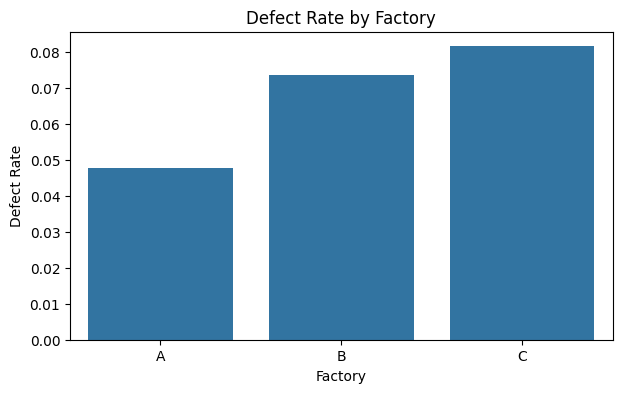

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 4))
sns.barplot(data=factory_summary, x="Factory", y="Defect_Rate")
plt.title("Defect Rate by Factory")
plt.ylabel("Defect Rate")
plt.show()

#### 문제 4. 공장 × 교대조별 불량률 계산

공장과 교대조를 함께 고려한 불량률을 계산하세요.

예를 들어 다음과 같은 값을 계산합니다.

- `P(불량=1 | Factory=A, Shift=Day)`
- `P(불량=1 | Factory=A, Shift=Night)`
- `P(불량=1 | Factory=B, Shift=Day)`
- `P(불량=1 | Factory=B, Shift=Night)`


Shift,Day,Night
Factory,,
A,0.040417,0.058380
B,0.063719,0.090703
C,0.077612,0.087678


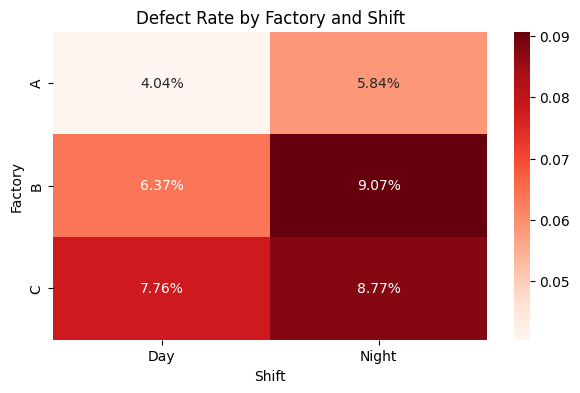

In [4]:
factory_shift_rate = pd.pivot_table(
    df,
    index="Factory",
    columns="Shift",
    values="Defect",
    aggfunc="mean"
)
display(factory_shift_rate)

plt.figure(figsize=(7, 4))
sns.heatmap(factory_shift_rate, annot=True, fmt=".2%", cmap="Reds")
plt.title("Defect Rate by Factory and Shift")
plt.show()

#### 문제 5. 공장 × 제품유형별 불량률 계산

공장과 제품 유형을 함께 고려한 불량률을 계산하세요.

Product_Type,Advanced,Premium,Standard
Factory,,,
A,0.051836,0.098485,0.035562
B,0.074349,0.123894,0.047085
C,0.076316,0.091278,0.068493


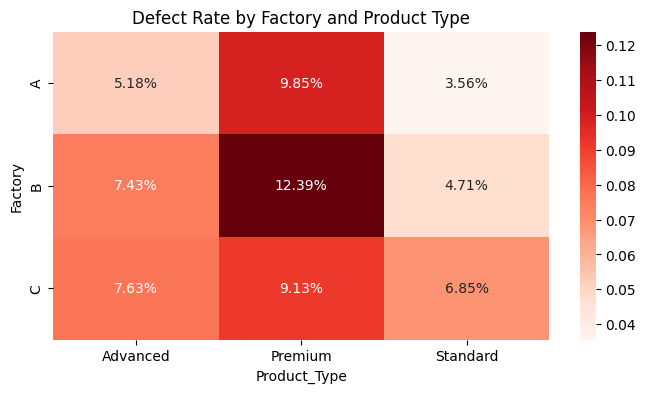

In [5]:
factory_product_rate = pd.pivot_table(
    df,
    index="Factory",
    columns="Product_Type",
    values="Defect",
    aggfunc="mean"
)

display(factory_product_rate)

plt.figure(figsize=(8, 4))
sns.heatmap(factory_product_rate, annot=True, fmt=".2%", cmap="Reds")
plt.title("Defect Rate by Factory and Product Type")
plt.show()

Product_Type,Advanced,Premium,Standard
Factory,,,
A,463,132,703
B,538,226,446
C,380,493,219


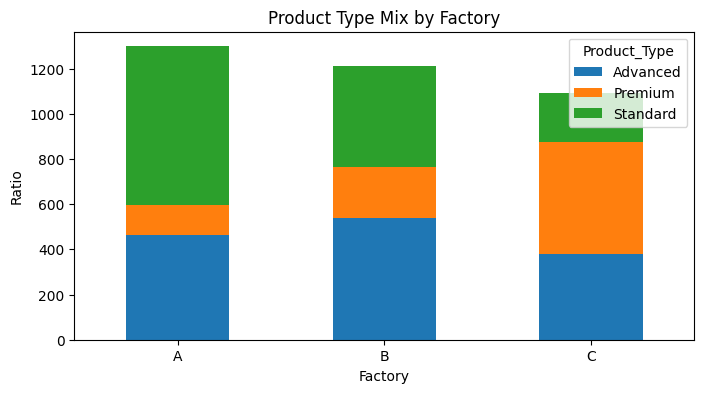

In [6]:
# 생산비중

product_mix = pd.crosstab(
    df["Factory"],
    df["Product_Type"],
    # normalize="index"
)
display(product_mix)

# pivot_table로 도 할수 있음
# product_mix = pd.pivot_table(
#     data=df2,
#     index = "Factory",
#     columns = "Product_Type",
#     values="Defect",
#     aggfunc="size",
#     fill_value=0
# )
# display(product_mix)

product_mix.plot(kind="bar", stacked=True, figsize=(8, 4))
plt.title("Product Type Mix by Factory")
plt.ylabel("Ratio")
plt.xticks(rotation=0)
plt.show()

#### 문제 6. 생산 배정 의사결정

Premium 제품 10,000개를 추가 생산해야 한다고 가정합니다.

공장 A, B, C 중 어느 공장에 배정하는 것이 가장 합리적인지 판단하세요.

단, 전체 공장별 불량률만 보지 말고, `Product_Type = Premium` 조건에서의 공장별 불량률을 기준으로 판단하세요.

In [7]:
premium_df = df[df["Product_Type"] == "Premium"]

# 1. 공장별 생산 건수
production_count = premium_df.groupby("Factory")["Defect"].size()

# 2. 공장별 불량 건수
defect_count = premium_df.groupby("Factory")["Defect"].sum()

# 3. 공장별 불량률
defect_rate = premium_df.groupby("Factory")["Defect"].mean()

# 4. 하나의 표로 합치기
premium_factory_summary = pd.DataFrame({
    "Production_Count": production_count,
    "Defect_Count": defect_count,
    "Defect_Rate": defect_rate
})

# 5. 불량률 기준 정렬
premium_factory_summary = (
    premium_factory_summary
    .sort_values("Defect_Rate")
    .reset_index()
)
display(premium_factory_summary)

# agg를 써서 한 번에
# premium_factory_summary = (
#     premium_df.groupby("Factory")
#     .agg(
#         Production_Count=("Defect", "size"),
#         Defect_Count=("Defect", "sum"),
#         Defect_Rate=("Defect", "mean")
#     )
#     .sort_values("Defect_Rate")
#     .reset_index()
# )

best_factory = premium_factory_summary.iloc[0]["Factory"]
best_rate = premium_factory_summary.iloc[0]["Defect_Rate"]

print(f"Premium 추가 생산 추천 공장: {best_factory}")
print(f"해당 공장의 Premium 조건부 불량률: {best_rate:.2%}")

,Factory,Production_Count,Defect_Count,Defect_Rate
0,C,493,45,0.091278
1,A,132,13,0.098485
2,B,226,28,0.123894


Premium 추가 생산 추천 공장: C
해당 공장의 Premium 조건부 불량률: 9.13%


#### 문제 7. 해석상 주의점 작성

전체 공장별 불량률만 보고 판단할 때 어떤 오류가 생길 수 있는지 설명하세요.

=> C공장은 전체 불량률이 높지만 Preminum 제품을 많이 생산하며 해당 제품의 불량률은 낮음